In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train_df = pd.read_csv('../input/titanic/train.csv')
test_df = pd.read_csv('../input/titanic/test.csv')
concat_df = pd.concat([train_df, test_df], ignore_index=True)

# **Exploratory Data Analysis**

In [3]:
concat_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
print(f'Train dimension: {train_df.shape}')
print(f'Test dimension: {test_df.shape}')
print(f'Concat dimension: {concat_df.shape}')

Train dimension: (891, 12)
Test dimension: (418, 11)
Concat dimension: (1309, 12)


In [5]:
concat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [6]:
concat_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [7]:
concat_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [8]:
print(f'Duplicated data: {concat_df.duplicated().sum()}')

Duplicated data: 0


## Plot missing values

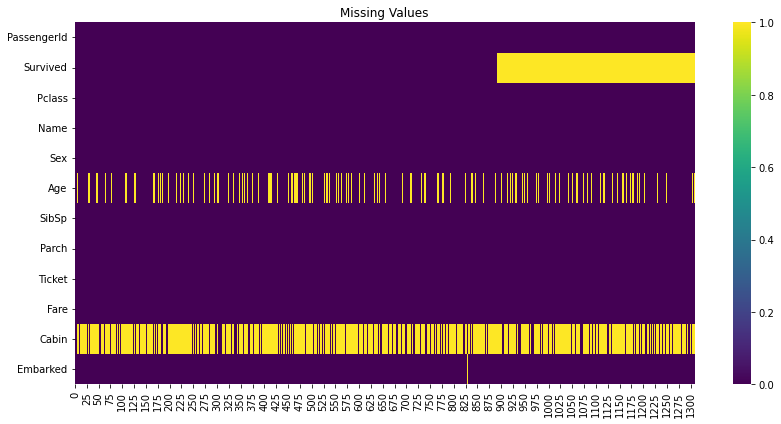

In [9]:
plt.figure(figsize=(12,6))
plt.title('Missing Values')
missing_vals = concat_df.isna().transpose()
sns.heatmap(missing_vals, cmap='viridis')
plt.tight_layout()

## Plot Columns Relationship

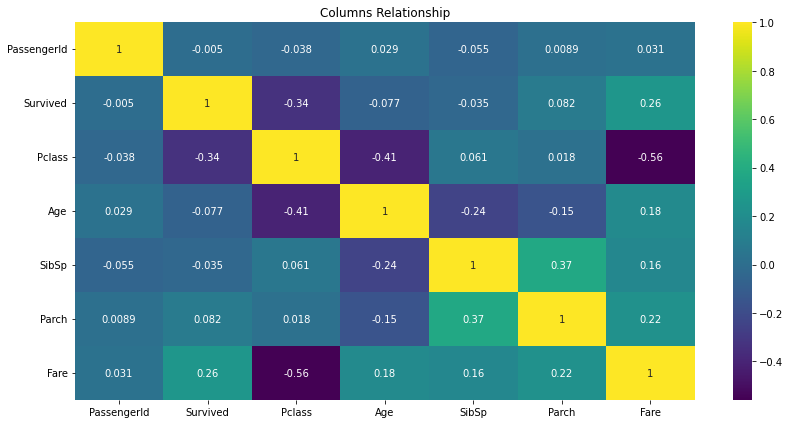

In [10]:
plt.figure(figsize=(12,6))
plt.title('Columns Relationship')
corr = concat_df.corr()
sns.heatmap(corr, annot=True, cmap='viridis')
plt.tight_layout()

# **Data Visualization**

## Data distributions

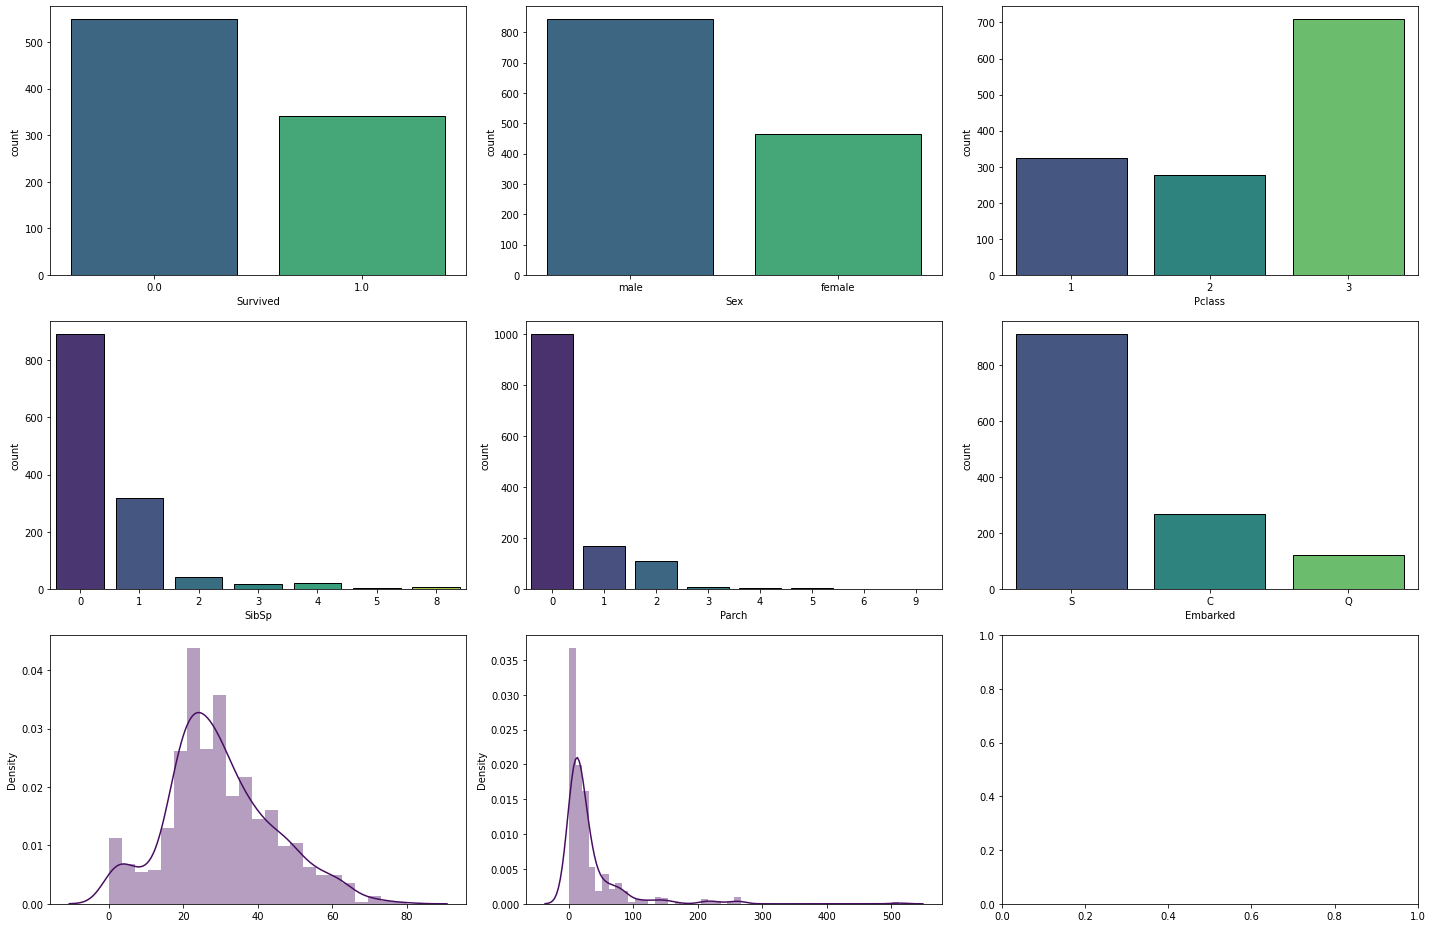

In [11]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(20,13))

sns.countplot(ax=axes[0,0] ,data=concat_df, x='Survived', palette='viridis', edgecolor='black')
sns.countplot(ax=axes[0,1] ,data=concat_df, x='Sex', palette='viridis', edgecolor='black')
sns.countplot(ax=axes[0,2] ,data=concat_df, x='Pclass', palette='viridis', edgecolor='black')
sns.countplot(ax=axes[1,0] ,data=concat_df, x='SibSp', palette='viridis', edgecolor='black')
sns.countplot(ax=axes[1,1] ,data=concat_df, x='Parch', palette='viridis', edgecolor='black')
sns.countplot(ax=axes[1,2] ,data=concat_df, x='Embarked', palette='viridis', edgecolor='black')
sns.distplot(ax=axes[2,0], x=concat_df.Age, color='#470d60',kde=True)
sns.distplot(ax=axes[2,1], x=concat_df.Fare, color='#470d60',kde=True)

plt.tight_layout()

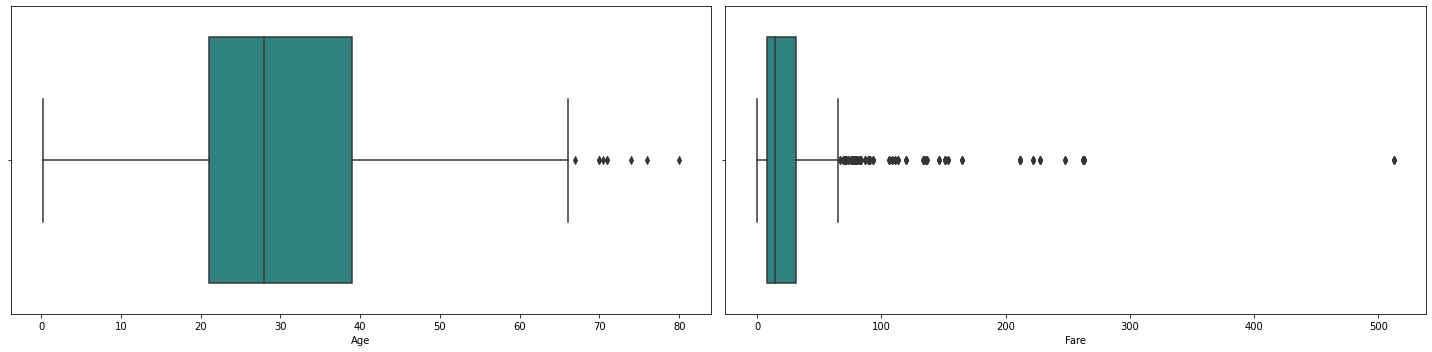

In [12]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(20,5))

sns.boxplot(ax=ax1, data=concat_df, x='Age', palette='viridis')
sns.boxplot(ax=ax2, data=concat_df, x='Fare', palette='viridis')

plt.tight_layout()

# **Feature Engineering**

In [13]:
class FE:
    def __init__(self, df):
        self.df = df
        
    def fill_na(self):
        avg_age = round(self.df.Age.mean(), 1)
        self.df.Age.fillna(avg_age, inplace=True)
        
        avg_fare = round(self.df.Fare.mean(), 4)
        self.df.Fare.fillna(avg_fare, inplace=True)
        
        mode_embarked = concat_df.Embarked.value_counts().index[0]
        self.df.Embarked.fillna('a', inplace=True)
        
        return self.df
    
    def drop_cols(self):
        self.df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
        return self.df

    def run_all(self):
        self.fill_na()
        self.drop_cols()
        
        return self.df[['PassengerId', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Fare', 'Survived']]

In [14]:
fe = FE(concat_df.copy())
cleaned_df = fe.run_all()

In [15]:
cleaned_df.head()

,PassengerId,Sex,Age,Pclass,SibSp,Parch,Embarked,Fare,Survived
0,1,male,22.0,3,1,0,S,7.2500,0.0
1,2,female,38.0,1,1,0,C,71.2833,1.0
2,3,female,26.0,3,0,0,S,7.9250,1.0
3,4,female,35.0,1,1,0,S,53.1000,1.0
4,5,male,35.0,3,0,0,S,8.0500,0.0


# **Data Preprocessing**

## One Hot Encoding & StandardScaling

In [16]:
def preprocessing(df):
    try:
        df = pd.get_dummies(df, columns=['Sex', 'Embarked'])
    except:
        pass
    
    return df

In [17]:
cleaned_df = preprocessing(cleaned_df)
cleaned_df.head()

,PassengerId,Age,Pclass,SibSp,Parch,Fare,Survived,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_a
0,1,22.0,3,1,0,7.2500,0.0,0,1,0,0,1,0
1,2,38.0,1,1,0,71.2833,1.0,1,0,1,0,0,0
2,3,26.0,3,0,0,7.9250,1.0,1,0,0,0,1,0
3,4,35.0,1,1,0,53.1000,1.0,1,0,0,0,1,0
4,5,35.0,3,0,0,8.0500,0.0,0,1,0,0,1,0


## Split Data 

In [18]:
from sklearn.model_selection import train_test_split

features = cleaned_df.drop(['PassengerId', 'Survived'], axis=1).columns.tolist()
X = cleaned_df[cleaned_df.Survived.isna() == False][features]
y = cleaned_df[cleaned_df.Survived.isna() == False].Survived

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.25, random_state=42)

## Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_x)
scaled_train_x = scaler.transform(train_x)
scaled_test_x = scaler.transform(test_x)

# **Model Training**

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [22]:
def models(models, model_names):
    for model, name in zip(models, model_names):
        try:
            model.fit(scaled_train_x, train_y)
            prediction = model.predict(scaled_test_x)

            accuracy  = accuracy_score(prediction, test_y)
            cv_score = np.mean(cross_val_score(model, scaled_train_x, train_y, cv=10))
            report = classification_report(prediction, test_y)
            print(f'{name}\nAccuracy: {accuracy}\nCross Val Score: {cv_score}\n\n{report}\n\n')
        except:
            print(name)

In [23]:
models_list = [LogisticRegression(), KNeighborsClassifier(), DecisionTreeClassifier(), SVC(), RandomForestClassifier()]
model_names = ['LogisticRegression', 'KNeighborsClassifier', 'DecisionTreeClassifier', 'SVC', 'RandomForestClassifier']
models(models_list, model_names)

LogisticRegression
Accuracy: 0.8071748878923767
Cross Val Score: 0.7979647218453189

              precision    recall  f1-score   support

         0.0       0.86      0.83      0.84       139
         1.0       0.73      0.77      0.75        84

    accuracy                           0.81       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



KNeighborsClassifier
Accuracy: 0.8026905829596412
Cross Val Score: 0.7905020352781547

              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84       138
         1.0       0.73      0.76      0.75        85

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.79       223
weighted avg       0.80      0.80      0.80       223



DecisionTreeClassifier
Accuracy: 0.7174887892376681
Cross Val Score: 0.7620081411126188

              precision    recall  f1-score   support

         0.0       0.75   

# **Test Data & Submission**

In [24]:
test = cleaned_df[cleaned_df.Survived.isna() == True]
scaled_test = scaler.transform(test[features])

In [25]:
model = SVC()
model.fit(scaled_train_x, train_y)
prediction = model.predict(scaled_test).astype(int)

In [26]:
prediction

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [27]:
output = pd.DataFrame({'PassengerId':test.PassengerId, 'Survived':prediction})
output

,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1
...,...,...
1304,1305,0
1305,1306,1
1306,1307,0
1307,1308,0


In [28]:
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
